In [1]:
from codebase.utils_ml import *
import pandas as pd
import dask.dataframe as dd

from tsfresh import (
    extract_features,  
    select_features
)
from tsfresh.utilities.dataframe_functions import impute

In [23]:
# plt.errorbar(np.arange(100),np.mean(features_7,axis=0),yerr=np.std(features_7,axis=0))
# plt.plot(features_4[0])

493

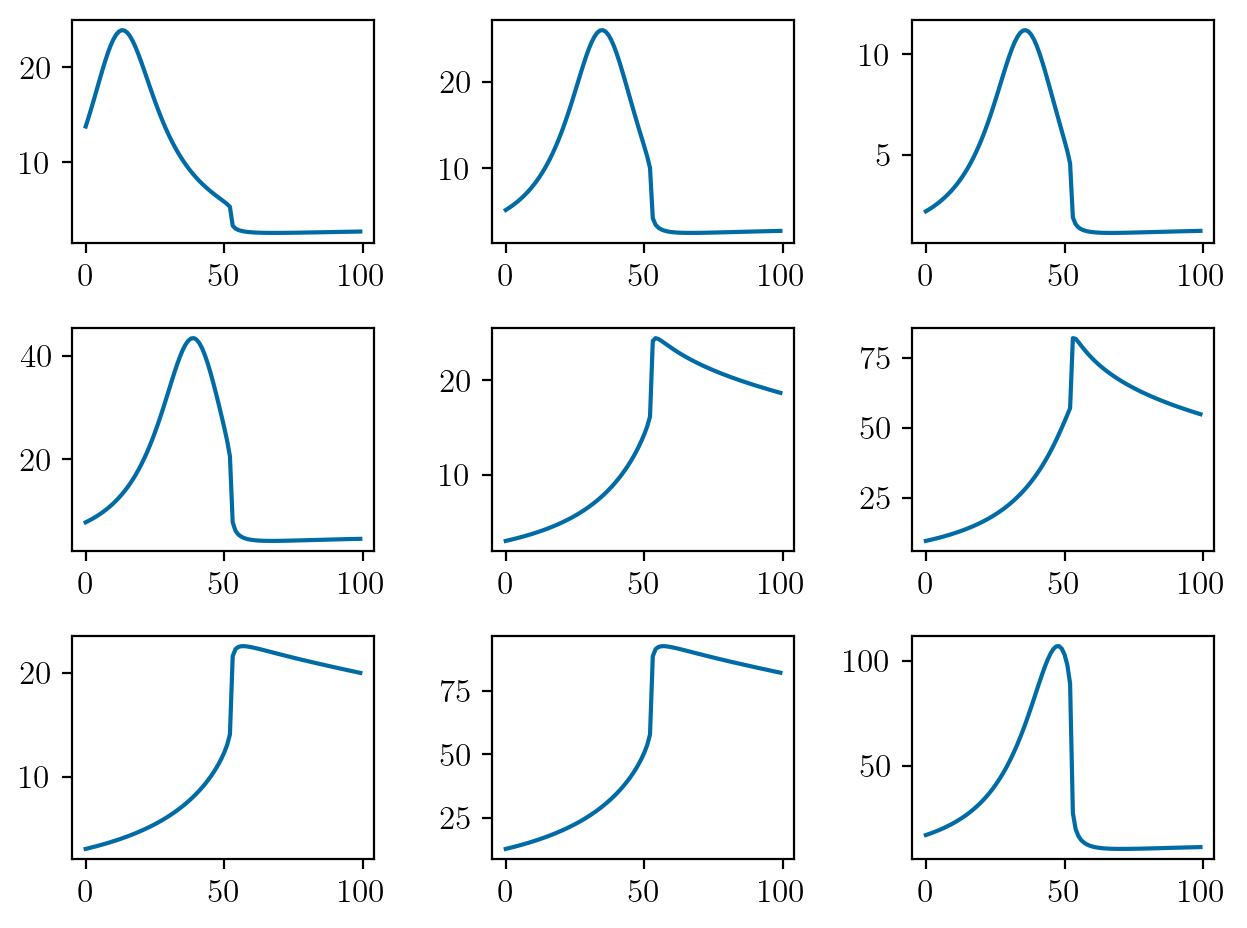

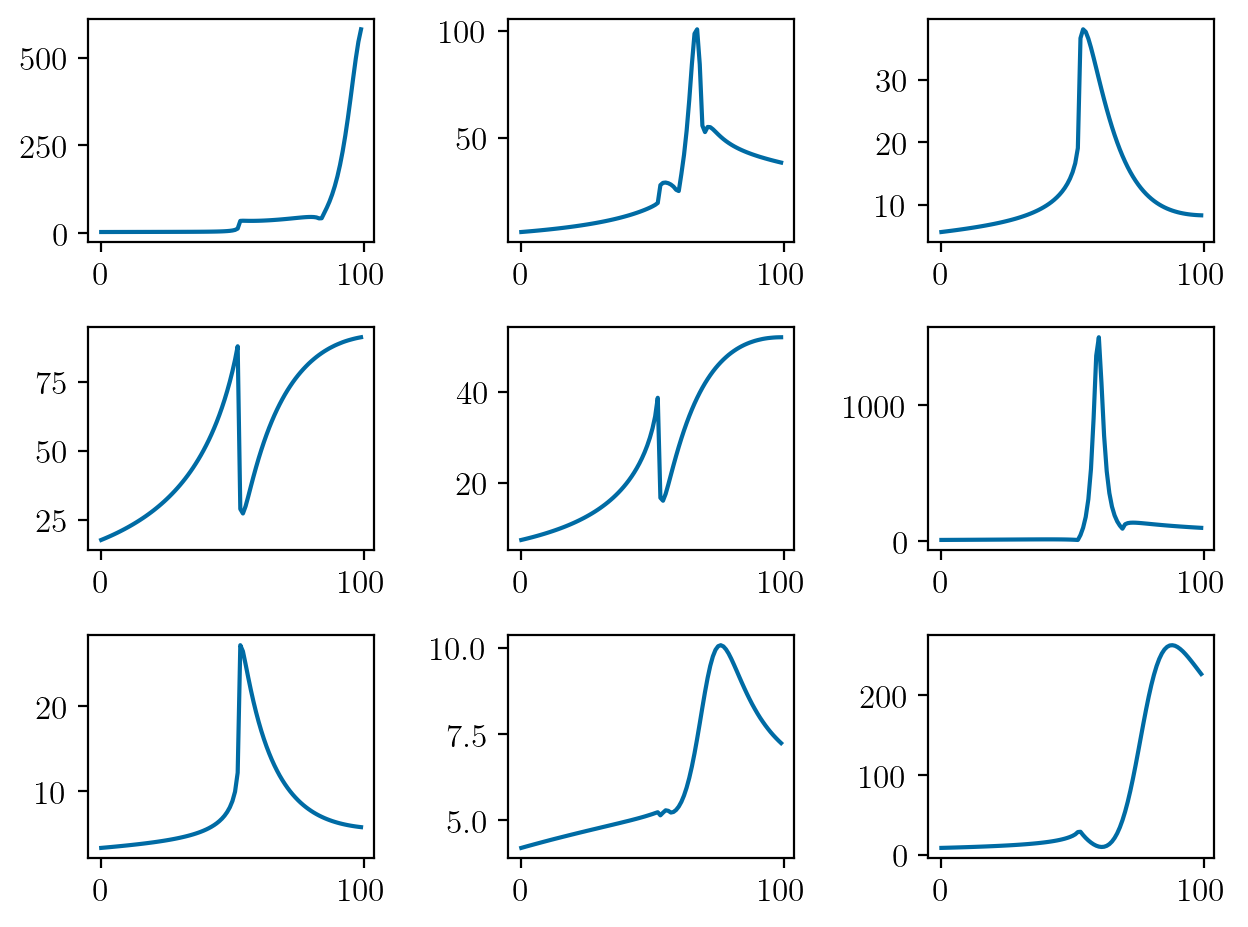

In [4]:
features_0 = np.array(np.load("data_8_sim/nfeatures_08/ModEsq00.pkl", allow_pickle=True))
features_1 = np.array(np.load("data_8_sim/nfeatures_08/ModEsq01.pkl", allow_pickle=True))
features_2 = np.array(np.load("data_8_sim/nfeatures_08/ModEsq02.pkl", allow_pickle=True))
features_3 = np.array(np.load("data_8_sim/nfeatures_08/ModEsq03.pkl", allow_pickle=True))
features_4 = np.array(np.load("data_8_sim/nfeatures_08/ModEsq04.pkl", allow_pickle=True))
features_5 = np.array(np.load("data_8_sim/nfeatures_08/ModEsq05.pkl", allow_pickle=True))
features_6 = np.array(np.load("data_8_sim/nfeatures_08/ModEsq06.pkl", allow_pickle=True))
features_7 = np.array(np.load("data_8_sim/nfeatures_08/ModEsq07.pkl", allow_pickle=True))

all_features = np.concatenate([features_0, features_1, features_2, features_3, 
                               features_4, features_5, features_6, features_7], axis=0)

label_arr = np.array([np.tile(i,features_0.shape[0]) for i in np.arange(0,8)]).flatten()

fig,axs = plt.subplots(3,3)
axs = axs.flatten()
for i in range(9):
    axs[i].plot(features_0[i])
fig.tight_layout()

fig,axs = plt.subplots(3,3)
axs = axs.flatten()
for i in range(9):
    axs[i].plot(features_7[i])
fig.tight_layout()
gc.collect()

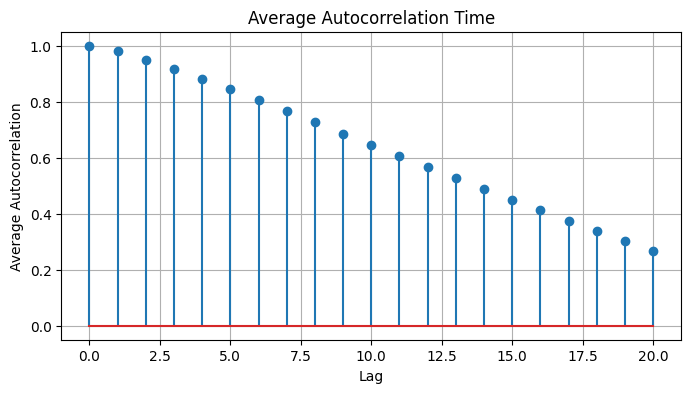

In [14]:
# Example dataset: Replace with your own array data
# Each row represents a separate time series

# Define the maximum lag to consider
max_lag = 20

def autocorrelation(x, lag):
    """
    Calculate the autocorrelation of a 1D array x at a specific lag.
    """
    n = len(x)
    x_mean = np.mean(x)
    c0 = np.sum((x - x_mean) ** 2) / n
    
    return np.sum((x[:n - lag] - x_mean) * (x[lag:] - x_mean)) / (n - lag) / c0

# Calculate autocorrelation for each series and lag
acf_values = np.zeros((all_features.shape[0], max_lag + 1))
for i, series in enumerate(all_features):
    for lag in range(max_lag + 1):
        acf_values[i, lag] = autocorrelation(series, lag)

# Compute the average autocorrelation across all series
avg_acf = np.mean(acf_values, axis=0)

# Plot the average autocorrelation
plt.figure(figsize=(8, 4))
plt.stem(range(max_lag + 1), avg_acf)
plt.xlabel('Lag')
plt.ylabel('Average Autocorrelation')
plt.title('Average Autocorrelation Time')
plt.grid()
plt.show()


In [ ]:
data_df = pd.DataFrame()
labels_df = pd.Series()

data_df['id'] = np.repeat(np.arange(all_features.shape[0]),all_features.shape[1])
data_df['time'] = np.tile(np.arange(all_features.shape[1]), all_features.shape[0])
data_df['feature'] = all_features.flatten()
data_df.to_parquet('data/data_df.parquet')

labels_df['labels'] = label_arr

data_df

,id,time,feature
0,0,0,13.753024
1,0,1,14.674004
2,0,2,15.638559
3,0,3,16.635180
4,0,4,17.650384
...,...,...,...
2399995,23999,95,222.277109
2399996,23999,96,237.572621
2399997,23999,97,248.774345
2399998,23999,98,255.216699


In [ ]:
gc.collect()
# Load data once
dask_df = dd.read_parquet('data/data_df.parquet')

# Extract features
extracted_features = extract_features(dask_df, column_id="id", column_sort="time",n_jobs=-1, disable_progressbar=False).compute()

# Handle any NaNs
impute(extracted_features)

# Convert labels to a Series (ensure it’s 1D if needed)
labels_series =  pd.Series(np.array(labels_df.to_numpy()[0]))

# Select relevant features
features_filtered = select_features(extracted_features, labels_series, multiclass=True)

# Save to a .npy file with memory-mapping enabled
np.save('data/features_filtered.npy', features_filtered.to_numpy())
gc.collect()

0

In [7]:
features_filtered

variable,feature__abs_energy,feature__absolute_maximum,feature__absolute_sum_of_changes,"feature__agg_autocorrelation__f_agg_""mean""__maxlag_40","feature__agg_autocorrelation__f_agg_""median""__maxlag_40","feature__agg_autocorrelation__f_agg_""var""__maxlag_40","feature__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""max""","feature__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""mean""","feature__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""min""","feature__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""var""",...,feature__symmetry_looking__r_0.2,feature__symmetry_looking__r_0.25,feature__symmetry_looking__r_0.30000000000000004,feature__symmetry_looking__r_0.35000000000000003,feature__time_reversal_asymmetry_statistic__lag_1,feature__time_reversal_asymmetry_statistic__lag_2,feature__time_reversal_asymmetry_statistic__lag_3,feature__variance,feature__variance_larger_than_standard_deviation,feature__variation_coefficient
id,,,,,,,,,,,,,,,,,,,,,
0,1.366759e+04,23.918039,31.698840,0.408902,0.418089,0.179896,22.663595,19.392079,16.016531,4.614539,...,1.0,1.0,1.0,1.0,-3.878319e+01,-9.674395e+01,-1.801483e+02,5.614541e+01,1.0,0.834981
1,1.553016e+04,25.935394,44.349551,0.138619,0.074365,0.325454,19.810890,16.191011,13.033462,5.346711,...,1.0,1.0,1.0,1.0,-1.048901e+00,-1.755551e+00,-2.157074e+00,6.528598e+01,1.0,0.851630
2,2.867975e+03,11.203798,19.230939,0.122892,0.049879,0.329015,8.378110,6.836979,5.446893,1.000022,...,1.0,1.0,1.0,1.0,-5.714397e-02,-6.180030e-02,-1.101976e-02,1.215478e+01,1.0,0.857636
3,4.167144e+04,43.422934,75.172240,0.084176,-0.009626,0.331067,30.626780,24.822289,19.408847,15.725694,...,1.0,1.0,1.0,1.0,1.750517e+00,1.199543e+01,3.180206e+01,1.808109e+02,1.0,0.875478
4,2.441234e+04,24.419825,27.135719,0.437924,0.510050,0.175845,4.322164,3.217947,1.941413,1.629511,...,1.0,1.0,1.0,1.0,8.680670e+01,1.785913e+02,2.759930e+02,5.801085e+01,1.0,0.558299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,6.594488e+03,20.485598,33.966174,-0.019661,-0.130338,0.296096,6.455342,5.681841,4.762355,1.355783,...,1.0,1.0,1.0,1.0,-1.514639e+00,-4.393932e+00,-7.792146e+00,1.869634e+01,1.0,0.629048
23996,1.860261e+05,111.959244,194.775368,0.013142,-0.050119,0.314281,30.655608,26.376577,21.757634,35.282181,...,1.0,1.0,1.0,1.0,-2.904348e+02,-7.350359e+02,-1.220344e+03,5.782400e+02,1.0,0.671593
23997,1.874118e+08,3321.007136,3999.064222,0.314733,0.251929,0.162396,-787.220459,-697.623596,-565.222770,-26745.286310,...,0.0,1.0,1.0,1.0,2.688172e+08,6.349339e+08,1.096198e+09,1.276319e+06,1.0,1.461175
